In [1]:
# import libraries
import numpy as np
import torch as torch
import torchvision
from torchvision import datasets, transforms, models
import time
import os
import copy
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torch.autograd import Variable
import random
from torch.nn import functional as F
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

In [2]:
num_epochs = 50
batch_size =128
patience=10
#'normal','dual-sample','mix-noise-signals','mix-without-noise-signals','meta'4

In [3]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


b_list=torch.tensor([[30,50,100,150,300,400,500]]).to(device)/1000
out_num=3

_,b_num=b_list.shape

data_dict=torch.load(r"G:\zhouxinxiang\volunters\simulation\data_dict.pth")

train_signals,train_parameters=data_dict['train']['Multi']
val_signals,val_parameters=data_dict['val']['Multi']

    
dataloaders_dict = torch.utils.data.DataLoader(train_signals,batch_size=batch_size,shuffle=True, num_workers=0)

In [4]:
softmax=nn.Softmax(1)
relu = nn.ReLU(inplace=False)
sigmoid = nn.Sigmoid()

def translation(code):
    factor=torch.tensor([[0.75,100.,0.8]]).to(device)
    code=code*factor
    d0=code[:,0].reshape(-1,1)
    d1=code[:,1].reshape(-1,1)   
    f0=code[:,2].reshape(-1,1) 
    f1=relu(1-f0)  
    signals=f0*torch.exp(-b_list*d0)+f1*torch.exp(-b_list*d1)
    parameters=torch.cat((d0/1000,d1/1000,f0,f1), dim=1)

    return signals,parameters
        

def init_parameter(model):
    if isinstance(model, nn.Linear):
        if model.weight is not None:
            init.kaiming_uniform_(model.weight.data)
        if model.bias is not None:
            init.normal_(model.bias.data)
    elif isinstance(model, nn.BatchNorm1d):
        if model.weight is not None:
            init.normal_(model.weight.data, mean=1, std=0.02)
        if model.bias is not None:
            init.constant_(model.bias.data, 0)
    elif isinstance(model, nn.BatchNorm2d):
        if model.weight is not None:
            init.normal_(model.weight.data, mean=1, std=0.02)
        if model.bias is not None:
            init.constant_(model.bias.data, 0)
    elif isinstance(model, nn.BatchNorm3d):
        if model.weight is not None:
            init.normal_(model.weight.data, mean=1, std=0.02)
        if model.bias is not None:
            init.constant_(model.bias.data, 0)
    else:
        pass 
            
def initialize_model(model,requires_grad):
    for param in model.parameters():
        init_parameter(param.data)
    return model

In [5]:
#train model
def train_model(model,dataloaders,criterion,optimizer,num_epochs):
    since = time.time()
    loss_history = [] 
    min_loss = 100.
    bad_epochs=0.
    for epoch in range(num_epochs):
        print("Epoch {}/{}".format(epoch, num_epochs-1))
        print("-"*10)
        running_loss = 0. 
        for inputs in dataloaders:  
            inputs=inputs.to(device)
            with torch.autograd.set_grad_enabled(True):
                X1=model(inputs) 
                outs1,parameters1=translation(X1) 
                loss =criterion(inputs,outs1)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            
        epoch_loss = running_loss 

        print("Loss for updata: {} ,number of bad_epochs:{}".format(epoch_loss,bad_epochs))
        loss_history.append(epoch_loss) 
        if epoch_loss<=min_loss:
            min_loss=epoch_loss
            best_model = copy.deepcopy(model.state_dict())
            bad_epochs=0.
        else:
            bad_epochs+=1.
            if bad_epochs == patience:
                print('Early stopping')
                break
    model.load_state_dict(best_model)
    time_elapsed = time.time() - since
    print("Training compete in {}m {}s".format(time_elapsed // 60, time_elapsed % 60))
    return model,loss_history

In [5]:
#model
hiden_num=64
class model(nn.Module):
    def __init__(self):
        super(model, self).__init__()
        self.NET = nn.Sequential()
        self.NET.add_module("Linear1",nn.Linear(b_num, hiden_num))
        self.NET.add_module("elu1",nn.ELU())
        self.NET.add_module("Linear2",nn.Linear(hiden_num, hiden_num))
        self.NET.add_module("elu2",nn.ELU())
        self.NET.add_module("Linear3",nn.Linear(hiden_num, hiden_num))
        self.NET.add_module("elu3",nn.ELU())
        self.NET.add_module("Linear4",nn.Linear(hiden_num, hiden_num))
        self.NET.add_module("elu4",nn.ELU())
        self.NET.add_module("Linear5",nn.Linear(hiden_num, hiden_num))
        self.NET.add_module("elu5",nn.ELU())
        self.NET.add_module("Linear6",nn.Linear(hiden_num, out_num))

    def forward(self, x):
        return torch.abs(self.NET(x))
    

In [6]:
#train parameters
model = initialize_model(model(),requires_grad=True)
model=model.double().to(device)
model.train() 
optimizer = optim.Adam(model.parameters(), lr = 0.001)  
criterion =  torch.nn.MSELoss()#torch.nn.L1Loss()#

In [8]:
#train
model,loss_history= train_model(model,dataloaders_dict,criterion,optimizer,num_epochs=num_epochs)

Epoch 0/49
----------
Loss for updata: 1.4997014227018914 ,number of bad_epochs:0.0
Epoch 1/49
----------
Loss for updata: 0.8337612299420599 ,number of bad_epochs:0.0
Epoch 2/49
----------
Loss for updata: 0.3284046130440861 ,number of bad_epochs:0.0
Epoch 3/49
----------
Loss for updata: 0.13415327740424884 ,number of bad_epochs:0.0
Epoch 4/49
----------
Loss for updata: 0.11541422911229417 ,number of bad_epochs:0.0
Epoch 5/49
----------
Loss for updata: 0.1118689029651969 ,number of bad_epochs:0.0
Epoch 6/49
----------
Loss for updata: 0.10842264155637776 ,number of bad_epochs:0.0
Epoch 7/49
----------
Loss for updata: 0.10684763354735576 ,number of bad_epochs:0.0
Epoch 8/49
----------
Loss for updata: 0.10535927175225684 ,number of bad_epochs:0.0
Epoch 9/49
----------
Loss for updata: 0.10446055221072792 ,number of bad_epochs:0.0
Epoch 10/49
----------
Loss for updata: 0.10296499062381832 ,number of bad_epochs:0.0
Epoch 11/49
----------
Loss for updata: 0.10125049514236031 ,number 

In [7]:
model_dict=torch.load(r"G:\zhouxinxiang\volunters\simulation\model_dict.pth")
model.load_state_dict(model_dict['FCNN'+'val'])

<All keys matched successfully>

In [8]:
model.eval() 

val_signals=val_signals.to(device)
val_parameters=val_parameters.to(device)

since = time.time()
X=model(val_signals) 
outs,parameters=translation(X)
time_elapsed = time.time() - since

diff_parameters=parameters-val_parameters

In [9]:
torch.mean(X,0)

tensor([1.0025, 0.9844, 1.0077], device='cuda:0', dtype=torch.float64,
       grad_fn=<MeanBackward1>)

In [10]:
time_elapsed/val_parameters.shape[0]

0.00020490074157714845

In [12]:
"""
parameter_dict=torch.load(r"G:\zhouxinxiang\volunters\simulation\parameter_dict.pth")
parameter_dict['FCNN'+'val']=parameters
torch.save(parameter_dict,r"G:\zhouxinxiang\volunters\simulation\parameter_dict.pth")

model_dict=torch.load(r"G:\zhouxinxiang\volunters\simulation\model_dict.pth")
model_dict['FCNN'+'val']=model.state_dict()
torch.save(model_dict,r"G:\zhouxinxiang\volunters\simulation\model_dict.pth")


error_dict=torch.load(r"G:\zhouxinxiang\volunters\simulation\error_dict.pth")
error_dict['FCNN'+'val']=diff_parameters
torch.save(error_dict,r"G:\zhouxinxiang\volunters\simulation\error_dict.pth")
"""

'\nparameter_dict=torch.load(r"G:\\zhouxinxiang\x0bolunters\\simulation\\parameter_dict.pth")\nparameter_dict[\'FCNN\'+\'val\']=parameters\ntorch.save(parameter_dict,r"G:\\zhouxinxiang\x0bolunters\\simulation\\parameter_dict.pth")\n\nmodel_dict=torch.load(r"G:\\zhouxinxiang\x0bolunters\\simulation\\model_dict.pth")\nmodel_dict[\'FCNN\'+\'val\']=model.state_dict()\ntorch.save(model_dict,r"G:\\zhouxinxiang\x0bolunters\\simulation\\model_dict.pth")\n\n\nerror_dict=torch.load(r"G:\\zhouxinxiang\x0bolunters\\simulation\\error_dict.pth")\nerror_dict[\'FCNN\'+\'val\']=diff_parameters\ntorch.save(error_dict,r"G:\\zhouxinxiang\x0bolunters\\simulation\\error_dict.pth")\n'

In [11]:
print(torch.mean(diff_parameters,dim=0))
print(torch.mean(X,dim=0))
print(torch.std(diff_parameters,dim=0))

tensor([ 8.1999e-07, -1.3315e-03,  6.5125e-03, -6.4768e-03], device='cuda:0',
       dtype=torch.float64, grad_fn=<MeanBackward1>)
tensor([1.0025, 0.9844, 1.0077], device='cuda:0', dtype=torch.float64,
       grad_fn=<MeanBackward1>)
tensor([0.0001, 0.0308, 0.0439, 0.0438], device='cuda:0', dtype=torch.float64,
       grad_fn=<StdBackward0>)


In [12]:
print(torch.mean(diff_parameters*1000,dim=0))
print(torch.std(diff_parameters*1000,dim=0))

tensor([ 8.1999e-04, -1.3315e+00,  6.5125e+00, -6.4768e+00], device='cuda:0',
       dtype=torch.float64, grad_fn=<MeanBackward1>)
tensor([ 0.1166, 30.7715, 43.9031, 43.7856], device='cuda:0',
       dtype=torch.float64, grad_fn=<StdBackward0>)


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


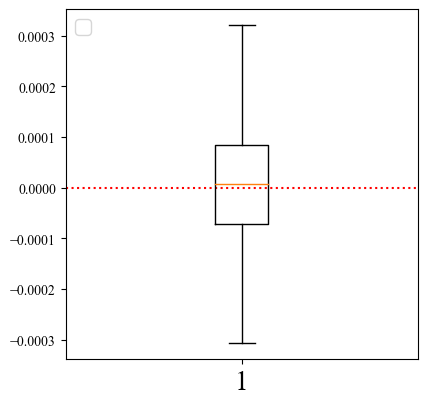

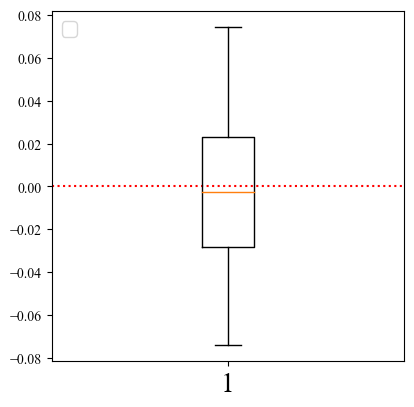

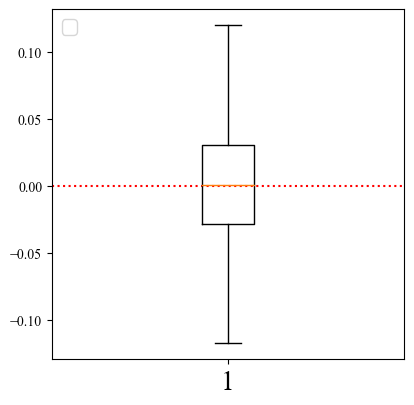

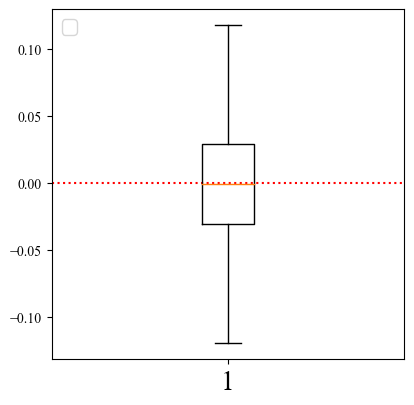

In [15]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

plt.rc('font',family='Times New Roman')
plt.figure(figsize=(10,10))
plt.subplot(2,2,1)
plt.xticks(fontsize=20)
#plt.yticks(np.arange(-10, 10, 5)/10000,fontsize=20)
plt.axhline(y=0., color='r', linestyle=':')
plt.boxplot(diff_parameters.cpu()[:,0].detach().numpy(),showfliers=False)
plt.xlabel("")
plt.ylabel("")
plt.legend(loc = 'upper left',fontsize=14)

plt.rc('font',family='Times New Roman')
plt.figure(figsize=(10,10))
plt.subplot(2,2,2)
plt.xticks(fontsize=20)
#plt.yticks(np.arange(-10, 10, 5)/10000,fontsize=20)
plt.axhline(y=0., color='r', linestyle=':')
plt.boxplot(diff_parameters.cpu()[:,1].detach().numpy(),showfliers=False)
plt.xlabel("")
plt.ylabel("")
plt.legend(loc = 'upper left',fontsize=14)

plt.rc('font',family='Times New Roman')
plt.figure(figsize=(10,10))
plt.subplot(2,2,3)
plt.xticks(fontsize=20)
#plt.yticks(np.arange(-10, 10, 5)/10000,fontsize=20)
plt.axhline(y=0., color='r', linestyle=':')
plt.boxplot(diff_parameters.cpu()[:,2].detach().numpy(),showfliers=False)
plt.xlabel("")
plt.ylabel("")
plt.legend(loc = 'upper left',fontsize=14)

plt.rc('font',family='Times New Roman')
plt.figure(figsize=(10,10))
plt.subplot(2,2,4)
plt.xticks(fontsize=20)
#plt.yticks(np.arange(-10, 10, 5)/10000,fontsize=20)
plt.axhline(y=0., color='r', linestyle=':')
plt.boxplot(diff_parameters.cpu()[:,3].detach().numpy(),showfliers=False)
plt.xlabel("")
plt.ylabel("")
plt.legend(loc = 'upper left',fontsize=14)

